## XMAC02 - Atividade Avaliativa 2
### Nome:
### Nro Matric:

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, expon

Nas questões de 1 a 4 você deve utilizar o dataset nba2k.csv.

In [2]:
df = pd.read_csv('nba2k.csv')
df.head()

,Unnamed: 0,full_name,rating,jersey,team,position,b_day,height,weight,salary,country,draft_year,draft_round,draft_peak,college,version
0,0,LeBron James,97,#23,Los Angeles Lakers,F,12/30/84,2.06,113.4,37436858,USA,2003,1,1,NaN,NBA2k20
1,1,Kawhi Leonard,97,#2,Los Angeles Clippers,F,06/29/91,2.01,102.1,32742000,USA,2011,1,15,San Diego State,NBA2k20
2,2,Giannis Antetokounmpo,96,#34,Milwaukee Bucks,F-G,12/06/94,2.11,109.8,25842697,Greece,2013,1,15,NaN,NBA2k20
3,3,Kevin Durant,96,#7,Brooklyn Nets,F,09/29/88,2.08,104.3,37199000,USA,2007,1,2,Texas,NBA2k20
4,4,James Harden,96,#13,Houston Rockets,G,08/26/89,1.96,99.8,38199000,USA,2009,1,3,Arizona State,NBA2k20


### Questão 1 [valor: 0,5 pt]
Obtenha a média, o desvio padrão e a mediana do peso (`weight`) dos pivôs (position = C) americanos da NBA, ou seja, dos jogadores que jogam na posição de pivô e que tenham country igual a USA.

In [3]:
df2 = df[(df['country'] == 'USA') & (df['position'] == 'C')]
print(df2['weight'].mean())
print(df2['weight'].std())
print(df2['weight'].median())

110.82173913043479
8.590690337470459
109.8


### Questão 2 [valor: 0,5 pt]
Gere um gráfico contendo três boxplots comparando o `rating` dos jogadores das posições G (armador), F (ala) e C (pivô).

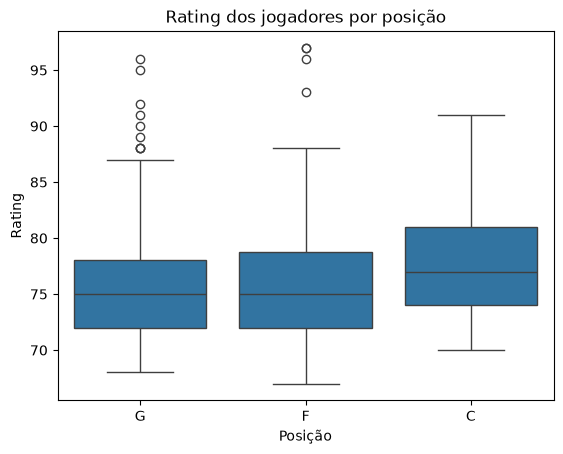

In [4]:
df3 = df[df['position'].isin(['G', 'F', 'C'])]
sns.boxplot(data=df3, x='position', y='rating', order=['G', 'F', 'C'])
plt.title('Rating dos jogadores por posição')
plt.xlabel('Posição')
plt.ylabel('Rating')
plt.show()

### Questão 3 [valor: 1,0 pt]
Gere um gráfico que exiba o peso dos 10 jogadores mais bem pagos da NBA, organizados em ordem ascendente, ou seja, do mais leve para o mais pesado.

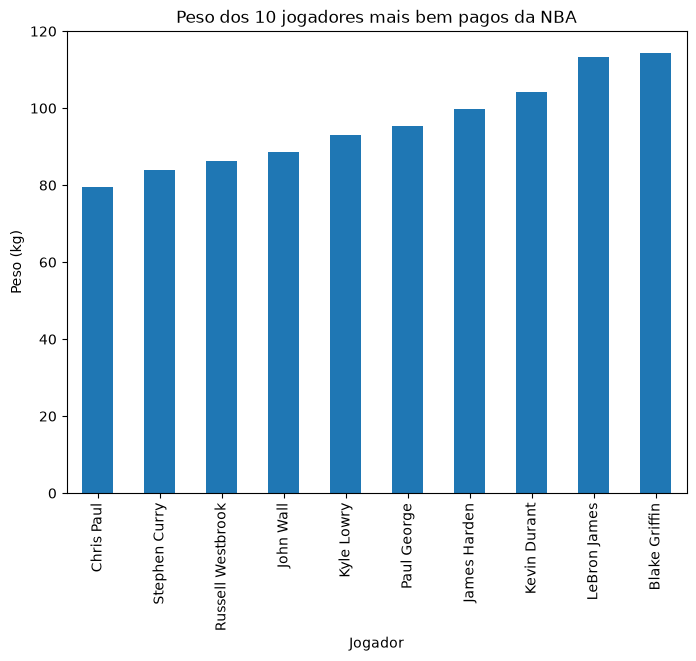

In [5]:
df2 = df.nlargest(10, 'salary')
df3 = df2.sort_values(by='weight', ascending=True)

plt.rcParams['figure.figsize'] = [8, 6]
df3.plot(x='full_name', y='weight', kind='bar', legend=False)
plt.title('Peso dos 10 jogadores mais bem pagos da NBA')
plt.xlabel('Jogador')
plt.ylabel('Peso (kg)')
plt.show()

### Questão 4 [valor: 1,0 pt]
Gere dois gráficos de pizza lado a lado que exibam: \
A) o percentual de jogadores por rodada do draft (`draft_round`: 1, 2 e Undrafted); \
B) o valor total pago aos jogadores de cada rodada do draft.

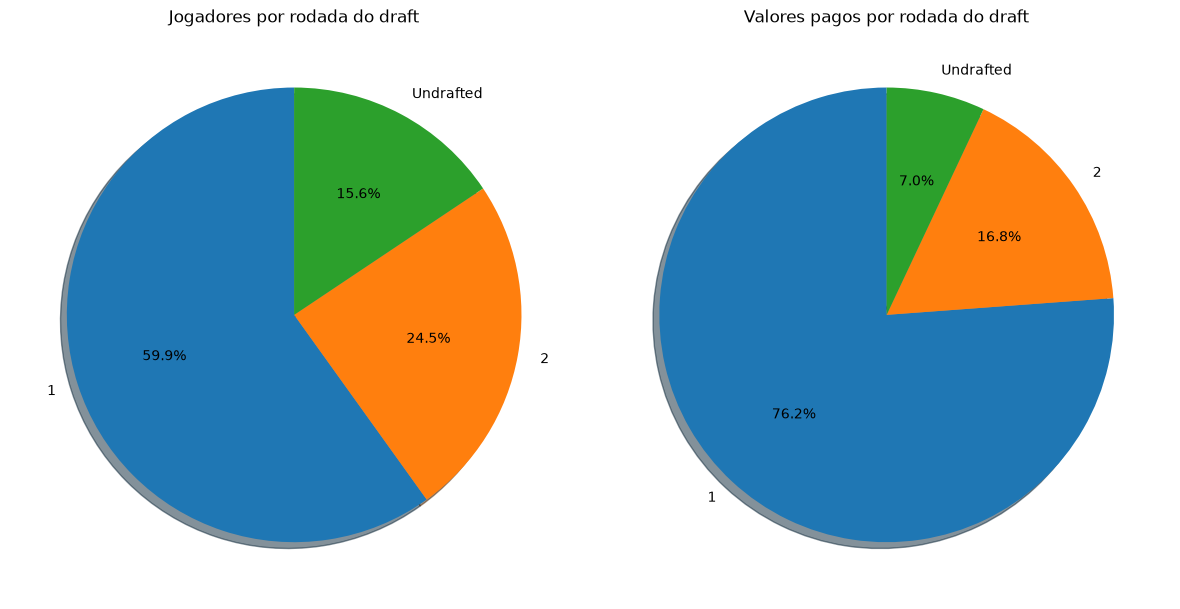

In [6]:
qtd = df['draft_round'].value_counts()
salarios = df.groupby('draft_round')['salary'].sum()

plt.rcParams['figure.figsize'] = [12, 6]
plt.subplot(1, 2, 1)
plt.pie(qtd, labels=qtd.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Jogadores por rodada do draft')
plt.subplot(1, 2, 2)
plt.pie(salarios, labels=salarios.index, autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Valores pagos por rodada do draft')
plt.tight_layout()
plt.show()

Nas questões de 5 a 8 deve-se usar os dataframes a seguir.

In [7]:
bike_day = pd.read_csv('day.csv')
students = pd.read_csv('student-por.csv', sep=';')

print('Bike — dados diários:', bike_day.shape)
print('Desempenho estudantil:', students.shape)

Bike — dados diários: (731, 16)
Desempenho estudantil: (649, 33)


### Questão 5 [valor: 0,75]

Utilize o DataFrame `bike_day`. Plote um gráfico de barras que mostre a média diária de locações de bike (`cnt`) por condição do tempo (`weathersit`). Substitua os códigos numéricos pelos nomes **Céu limpo** (1), **Nublado/Névoa** (2) e **Chuva/Neve leve** (3).

,media_alugueis
weathersit,
Céu limpo,4876.79
Nublado/Névoa,4035.86
Chuva/Neve leve,1803.29


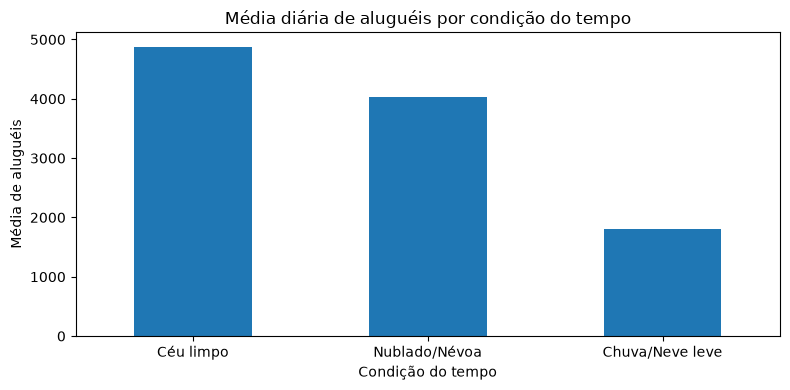

In [8]:
nomes_tempo = {
    1: 'Céu limpo',
    2: 'Nublado/Névoa',
    3: 'Chuva/Neve leve',
}

media_tempo = (
    bike_day.groupby('weathersit')['cnt']
    .mean()
    .rename(index=nomes_tempo)
    .rename('media_alugueis')
)

display(media_tempo.to_frame().round(2))

ax = media_tempo.plot(kind='bar', figsize=(8, 4))
ax.set_title('Média diária de aluguéis por condição do tempo')
ax.set_xlabel('Condição do tempo')
ax.set_ylabel('Média de aluguéis')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### Questão 6 [valor: 0,75]

Utilize o DataFrame `students`.

1. Agrupe os estudantes pelo número de reprovações anteriores (`failures`).
2. Para cada categoria, obtenha:
   - a quantidade de estudantes;
   - a média da nota final (`G3`);
3. Armazene as duas medidas em um novo DataFrame com nomes de colunas claros.
4. Construa um **gráfico de linha** da média de `G3` em função do número de reprovações.

,quantidade,media_nota_final
failures,,
0,549,12.51
1,70,8.64
2,16,8.81
3,14,8.07


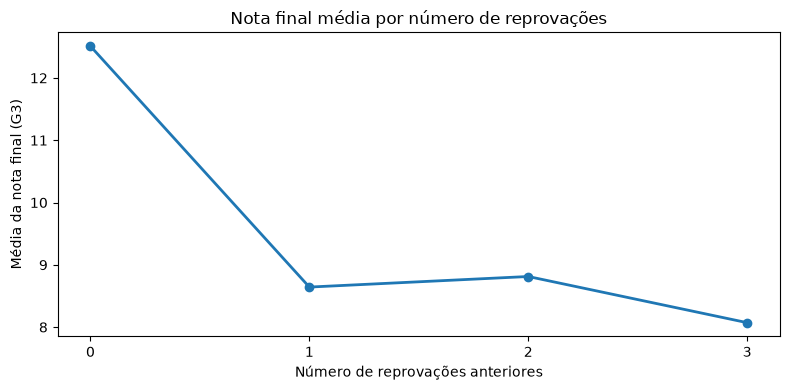

In [9]:
resumo_reprov = (
    students.groupby('failures')
    .agg(
        quantidade=('G3', 'size'),
        media_nota_final=('G3', 'mean')
    )
)

display(resumo_reprov.round(2))

ax = resumo_reprov['media_nota_final'].plot(
    kind='line', marker='o', linewidth=2, figsize=(8, 4)
)
ax.set_title('Nota final média por número de reprovações')
ax.set_xlabel('Número de reprovações anteriores')
ax.set_ylabel('Média da nota final (G3)')
ax.set_xticks(resumo_reprov.index)
plt.tight_layout()
plt.show()

### Questão 7 [valor: 0,5]

Utilize o DataFrame `students`. Construa um gráfico de barras agrupado pelo tipo de endereço (`address`: U = urbano, R = rural) que mostre a quantidade de alunos com e sem Internet em casa.

internet,no,yes
address,,
R,68,129
U,83,369


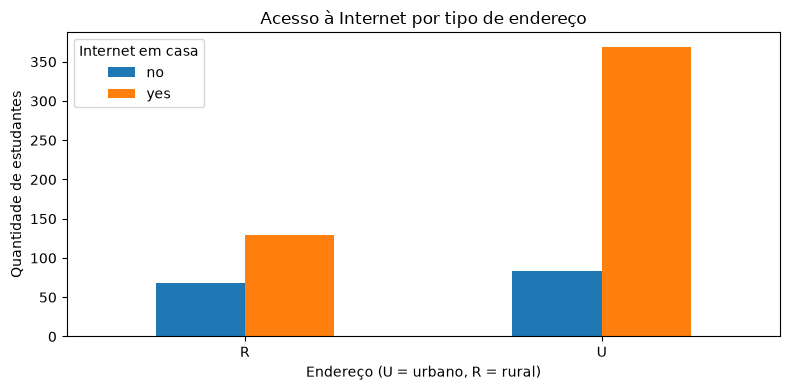

In [10]:
tabela_end_internet = pd.crosstab(students['address'], students['internet'])
display(tabela_end_internet)

ax = tabela_end_internet.plot(kind='bar', figsize=(8, 4))
ax.set_title('Acesso à Internet por tipo de endereço')
ax.set_xlabel('Endereço (U = urbano, R = rural)')
ax.set_ylabel('Quantidade de estudantes')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Internet em casa')
plt.tight_layout()
plt.show()

### Questão 8 [valor: 1,0]

Utilize o DataFrame `students`.

1. Investigue a relação entre a escolaridade da mãe (`Medu`: 0 = nenhuma ... 4 = ensino superior) e a intenção de cursar o ensino superior (`higher`).
2. Construa uma tabela de contingência **normalizada por linha**: cada linha deverá mostrar as proporções de respostas `yes` e `no` dentro daquela categoria de escolaridade da mãe.
3. Exiba os valores como percentuais, arredondados para uma casa decimal.
4. Construa um **gráfico de barras empilhadas**.
5. Escreva uma interpretação breve dos resultados.

higher,no,yes
Medu,,
0,16.7%,83.3%
1,18.9%,81.1%
2,14.5%,85.5%
3,8.6%,91.4%
4,1.1%,98.9%


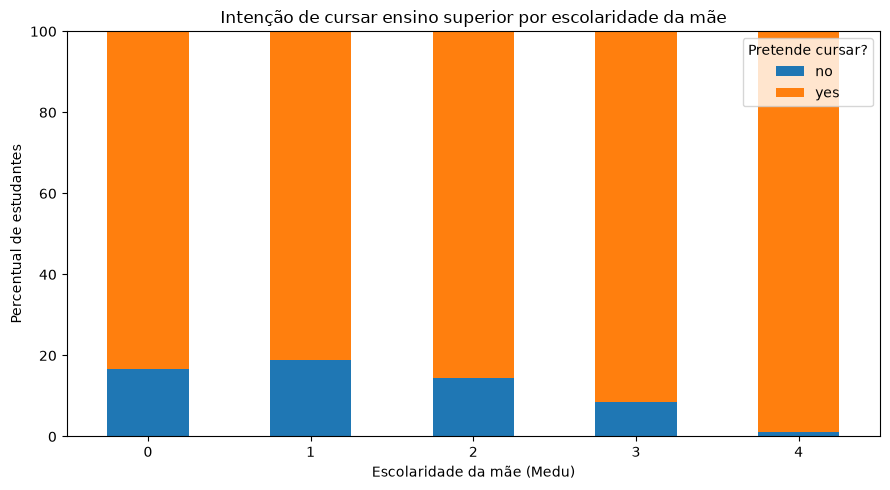

In [11]:
proporcao = pd.crosstab(
    index=students['Medu'],
    columns=students['higher'],
    normalize='index',
)

percentual = proporcao.mul(100)
display(percentual.round(1).astype(str) + '%')

ax = percentual.plot(kind='bar', stacked=True, figsize=(9, 5))
ax.set_title('Intenção de cursar ensino superior por escolaridade da mãe')
ax.set_xlabel('Escolaridade da mãe (Medu)')
ax.set_ylabel('Percentual de estudantes')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Pretende cursar?')
plt.tight_layout()
plt.show()

# Interpretação: de modo geral, quanto maior a escolaridade da mãe, maior o percentual de
# estudantes que pretendem cursar o ensino superior (de ~81% em Medu = 1 para ~99% em Medu = 4).
# A categoria 0 tem apenas 6 alunos, então sua proporção deve ser interpretada com cautela.

Nas questões 9 e 10 considere a Distribuição Normal (Aula 12).

### Questão 9 [valor: 1,0]
Pacotes de café são preenchidos com um peso médio de 500 g, com um desvio padrão de 8 g. Admitindo-se que os pesos estão normalmente distribuídos, determine: \
a) a porcentagem de pacotes com mais de 510 g; \
b) a porcentagem de pacotes com peso entre 490 g e 505 g; \
c) em um lote de 2.000 pacotes, quantos pacotes devem pesar menos de 485 g.

In [12]:
mu, sigma = 500, 8

a = norm.sf(510, mu, sigma)
b = norm.cdf(505, mu, sigma) - norm.cdf(490, mu, sigma)
c = 2000 * norm.cdf(485, mu, sigma)

print(f'a) {a * 100:.2f}%')
print(f'b) {b * 100:.2f}%')
print(f'c) aproximadamente {c:.0f} pacotes')

a) 10.56%
b) 62.84%
c) aproximadamente 61 pacotes


### Questão 10 [valor: 1,0]
A vida útil de certo modelo de lâmpada é normalmente distribuída, com média de 1.200 horas e desvio padrão de 150 horas. \
a) O fabricante deseja estabelecer uma garantia de modo que apenas 2% das lâmpadas sejam substituídas antes da expiração da garantia. Qual deve ser o prazo (em horas)? Dica: use a função ppf \
b) Construa um gráfico da função densidade de probabilidade entre μ - 3σ e μ + 3σ, destacando a área correspondente às lâmpadas que falham antes do prazo de garantia.

a) Prazo de garantia: 891.9 horas


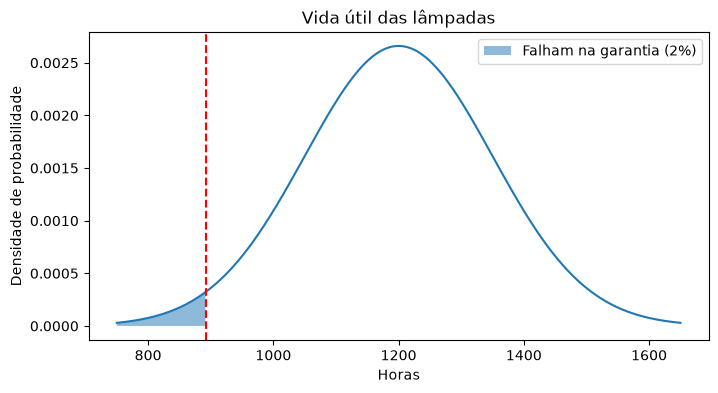

In [13]:
mu, sigma = 1200, 150

garantia = norm.ppf(0.02, mu, sigma)
print(f'a) Prazo de garantia: {garantia:.1f} horas')

eixoX = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 1000)
eixoY = norm.pdf(eixoX, mu, sigma)

plt.figure(figsize=(8, 4))
sns.lineplot(x=eixoX, y=eixoY)
plt.fill_between(eixoX, eixoY, where=eixoX <= garantia, alpha=0.5, label='Falham na garantia (2%)')
plt.axvline(garantia, color='red', linestyle='--')
plt.title('Vida útil das lâmpadas')
plt.xlabel('Horas')
plt.ylabel('Densidade de probabilidade')
plt.legend()
plt.show()

Nas questões 11 e 12 considere a Distribuição Exponencial (Aula 13).

### Questão 11 [valor: 1,0]
Uma central de suporte recebe, em média, 9 chamados por hora. Considere que os chamados seguem um processo de Poisson homogêneo.

a) Qual é o tempo médio de espera, em minutos, entre dois chamados consecutivos?

b) Qual é a probabilidade de que o próximo chamado ocorra em menos de 4 minutos?

c) Qual é a probabilidade de que o tempo de espera ultrapasse 10 minutos?

d) Qual é a probabilidade de que o próximo chamado ocorra entre 5 e 10 minutos?

In [14]:
lamb = 9 / 60          # chamados por minuto
media = 1 / lamb

print(f'a) {media:.2f} minutos')
print(f'b) {expon.cdf(4, scale=media):.4f}')
print(f'c) {expon.sf(10, scale=media):.4f}')
print(f'd) {expon.cdf(10, scale=media) - expon.cdf(5, scale=media):.4f}')

a) 6.67 minutos
b) 0.4512
c) 0.2231
d) 0.2492


### Questão 12 [valor: 1,0]
Um servidor recebe, em média, 20 requisições por minuto, seguindo um processo de Poisson homogêneo. Trabalhe com o tempo em **segundos**.

a) Gere 10.000 tempos de espera entre requisições consecutivas.

b) Construa um histograma dos valores simulados.

c) Calcule a média e o desvio padrão dos tempos simulados e compare com os valores teóricos da distribuição.

d) Calcule a proporção de tempos de espera inferiores a 2 segundos e compare com a probabilidade teórica.

e) Determine o tempo t para o qual existe uma probabilidade de 90% de que a próxima requisição ocorra até esse instante e indique-o em um gráfico da função densidade de probabilidade.

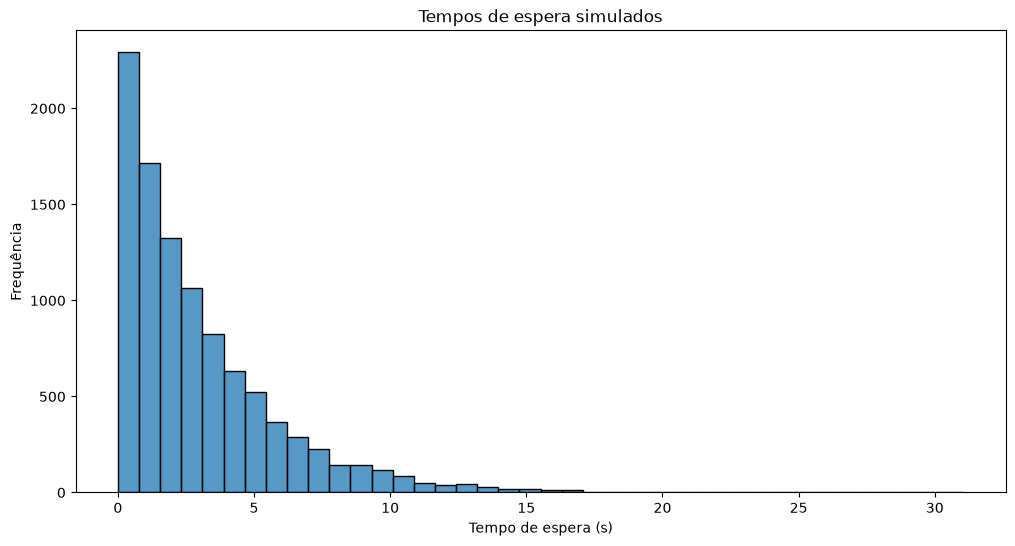

Média simulada: 3.0090 | teórica: 3.0000
Desvio simulado: 2.9896 | teórico: 3.0000
P(T < 2) simulada: 0.4846 | teórica: 0.4866
t para 90%: 6.91 segundos


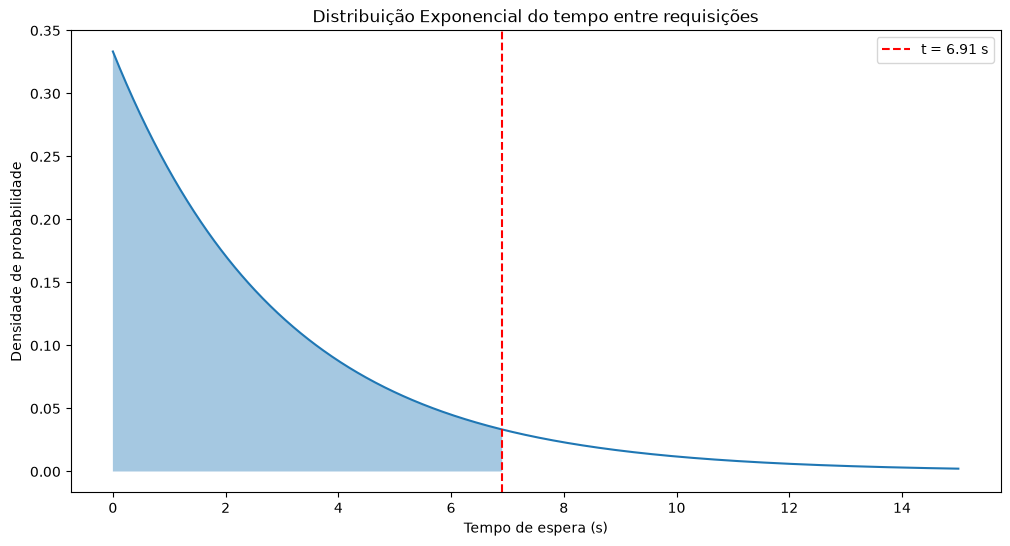

In [15]:
lamb = 20 / 60         # requisições por segundo
media = 1 / lamb

# a)
tempos = np.random.exponential(scale=media, size=10000)

# b)
sns.histplot(tempos, bins=40)
plt.title('Tempos de espera simulados')
plt.xlabel('Tempo de espera (s)')
plt.ylabel('Frequência')
plt.show()

# c)
print(f'Média simulada: {tempos.mean():.4f} | teórica: {expon.mean(scale=media):.4f}')
print(f'Desvio simulado: {tempos.std():.4f} | teórico: {expon.std(scale=media):.4f}')

# d)
print(f'P(T < 2) simulada: {np.mean(tempos < 2):.4f} | teórica: {expon.cdf(2, scale=media):.4f}')

# e)
t90 = expon.ppf(0.90, scale=media)
print(f't para 90%: {t90:.2f} segundos')

eixoX = np.linspace(0, 15, 1000)
eixoY = expon.pdf(eixoX, scale=media)
sns.lineplot(x=eixoX, y=eixoY)
plt.fill_between(eixoX, eixoY, where=eixoX <= t90, alpha=0.4)
plt.axvline(t90, color='red', linestyle='--', label=f't = {t90:.2f} s')
plt.title('Distribuição Exponencial do tempo entre requisições')
plt.xlabel('Tempo de espera (s)')
plt.ylabel('Densidade de probabilidade')
plt.legend()
plt.show()